## **Part A | Defining the Question**

#### **1. Objectives**  
For a final project in graduate school, I was tasked with acting as the Boulder County Assessor's Office hired me to address the following objectives:  
- **Ensure Assessment Accuracy**: Improve fairness and equity in property valuations to ensure taxes are distributed appropriately.  
- **Identify Demand Trends**: Highlight key housing market trends to guide city policy and incentives for builders.  
- **Analyze Price Drivers**: Understand the most influential factors driving property prices and how they vary across neighborhoods and property types.  

---

#### **2. Population of Interest and Available Data**  
- **Population of Interest**: All properties and homeowners in **Boulder County**.  
- **Available Data**:  
   - **Property**: General property information, including location and subdivision codes.  
   - **Building**: Details such as design, quality, square footage, and features.  
   - **Land**: Lot size in acreage and square footage.  
   - **Sales**: Sales transactions, including prices and transaction dates.  
   - **Time Trend Adjustments**: Adjustments for property values over time.  
   - **Valuations**: Appraised and assessed property values.  
- **Impact on Analysis**:  
   - **Strengths**: Comprehensive coverage of property characteristics, sales history, and adjustments for inflation trends.  
   - **Limitations**: Missing values in fields like basement square footage, land assessed value, and home quality scores may affect analysis accuracy.  
   - **Effects on Analysis**: Imputation and data preprocessing will be critical to maintain data integrity, especially for models like KNN regression.  

---

#### **3. Interesting, Specific, and Actionable Questions**  
The following questions guide the analysis to address the objectives:  

1. **Assessment Accuracy**:  
   *How does assessing properties by subdivisions compare to market area-based assessments in improving the accuracy and equity of property valuations?*  
   - **Purpose**: Determine whether localized assessments better capture property-specific influences, such as square footage and acreage.  

2. **Demand Trends**:  
   *What types of homes are most in demand based on sales data from the last two years and the most recent 10% of sales? How can this guide policies or incentives for future construction?*  
   - **Purpose**: Identify features driving demand (e.g., 3-4 bedrooms, finished basements, large lot sizes) and align housing policies with market needs.  

3. **Price Drivers**:  
   *What are the key factors influencing property prices, and how do they vary across single-family homes, multi-unit properties, and other types of dwellings?*  
   - **Purpose**: Quantify how property characteristics (e.g., square footage, home quality, lot size) affect home valuations across property types.  

## **Part B | Getting the Data**

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ttest_ind
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.ticker as ticker

# Part B: Load the Datasets
# Update file paths based on the new provided structure
file_paths = {
    "building": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/building.csv",
    "land": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/land.csv",
    "property": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/property.csv",
    "sales": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/sales.csv",
    "time_trend_adjustments": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/time_trend_adjustments.csv",
    "valuations": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/valuations.csv",
}

# Load the datasets
building_df = pd.read_csv(file_paths["building"])
land_df = pd.read_csv(file_paths["land"])
property_df = pd.read_csv(file_paths["property"])
sales_df = pd.read_csv(file_paths["sales"])
time_trend_df = pd.read_csv(file_paths["time_trend_adjustments"])
valuations_df = pd.read_csv(file_paths["valuations"])

Data loaded successfully. Moving to clean and prepare for analysis.

In [4]:
# Filter the most recent 10% of sales data
sales_df['transaction_date'] = pd.to_datetime(sales_df['transaction_date'])
sales_df = sales_df.sort_values(by='transaction_date', ascending=False)
recent_sales = sales_df.head(int(len(sales_df) * 0.10))

Recent 10% of sales data has been extracted for analysis.

**Why Use the Most Recent 10% of Sales Data?**  
The most recent 10% of sales data was selected to reflect current market conditions as accurately as possible.  
- This approach ensures that any trends or insights derived align with the **most up-to-date property values**.  
- It minimizes the risk of outdated or irrelevant sales prices affecting the analysis, particularly in rapidly changing housing markets.

In [5]:
# Melt and tidy time_trend_adjustments table
time_trend_tidy = time_trend_df.melt(id_vars=['year', 'month'], var_name='market_area_column', value_name='adjustment_factor')
time_trend_tidy['market_area'] = time_trend_tidy['market_area_column'].str.extract(r'(\d+)$').astype(int)

# Merge recent sales with property and building datasets
recent_sales = recent_sales.merge(property_df[['strap', 'market_area']], on='strap', how='left')
recent_sales = recent_sales.merge(building_df[['strap', 'total_finished_sqft', 'nbr_bed_room', 'nbr_rooms_nobath', 'quality', 'design']],
                                  on='strap', how='left')

# Merge time trend adjustments for inflation-adjusted sales price
recent_sales['year'] = recent_sales['transaction_date'].dt.year
recent_sales['month'] = recent_sales['transaction_date'].dt.month
recent_sales = recent_sales.merge(time_trend_tidy, on=['market_area', 'year', 'month'], how='left')
recent_sales['adjustment_factor'] = recent_sales['adjustment_factor'].fillna(1)
recent_sales['adjusted_sales_price'] = recent_sales['price'] * recent_sales['adjustment_factor']


Inflation-adjusted sales price calculated for all homes.

In [6]:
# Feature Engineering
# Average Room Size
recent_sales['avg_room_size'] = recent_sales['total_finished_sqft'] / recent_sales['nbr_rooms_nobath']
# Handle Missing Quality and Map Scores
recent_sales['quality'] = recent_sales['quality'].fillna('UNKNOWN').str.upper().str.strip()
quality_mapping = {'POOR': 1, 'FAIR': 2, 'AVERAGE': 3, 'GOOD': 4, 'EXCELLENT': 5, 'VERY GOOD': 4.5, 'UNKNOWN': 0}
recent_sales['home_quality_score'] = recent_sales['quality'].apply(lambda x: quality_mapping.get(x, 0))
# Price per Square Foot
recent_sales['price_per_sqft'] = recent_sales['adjusted_sales_price'] / recent_sales['total_finished_sqft']

New features 'avg_room_size', 'home_quality_score', and 'price_per_sqft' successfully created.

## **Part C | Exploratory Data Analysis (EDA)**

In [7]:
# Step 1: Understanding the structure and content of the data
print(recent_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1106 entries, 0 to 1105
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   strap                 1106 non-null   object        
 1   transaction_date      1106 non-null   datetime64[ns]
 2   sales_cd              1106 non-null   object        
 3   sales_cd_dscr         1106 non-null   object        
 4   price                 1106 non-null   int64         
 5   market_area           1106 non-null   int64         
 6   total_finished_sqft   995 non-null    float64       
 7   nbr_bed_room          1106 non-null   float64       
 8   nbr_rooms_nobath      1106 non-null   float64       
 9   quality               1106 non-null   object        
 10  design                1106 non-null   object        
 11  year                  1106 non-null   int32         
 12  month                 1106 non-null   int32         
 13  market_area_column

The data contains 1106 rows and 19 columns, with key variables including:
  - `adjusted_sales_price` (target variable)
  - `total_finished_sqft` (size of home)
  - `home_quality_score` (categorical home quality)

In [8]:
# Check for missing values
print(recent_sales.isna().sum())

strap                     0
transaction_date          0
sales_cd                  0
sales_cd_dscr             0
price                     0
market_area               0
total_finished_sqft     111
nbr_bed_room              0
nbr_rooms_nobath          0
quality                   0
design                    0
year                      0
month                     0
market_area_column      306
adjustment_factor         0
adjusted_sales_price      0
avg_room_size           111
home_quality_score        0
price_per_sqft          111
dtype: int64


### Insights on Missing Values
- **Home Quality Score**: Significant missing values (`541 rows`) are likely due to older homes or incomplete records.  
- **Total Finished Square Footage**: `111 rows` missing may indicate incomplete property records, particularly for smaller or irregular homes.  
- **Action Taken**: Rows with missing `home_quality_score` were filled with `0 (UNKNOWN)` to retain data integrity while allowing for analysis.  

**Observations**:
- The "EXCELLENT" and "GOOD" home quality categories are underrepresented in the most recent 10% of sales. 
- This could be due to either data gaps or the fact that these homes rarely sell, which impacts analysis of high-demand homes.
- Recommendation: Investigate earlier sales data or expand the time frame to ensure sufficient representation.

Text(0, 0.5, 'Frequency')

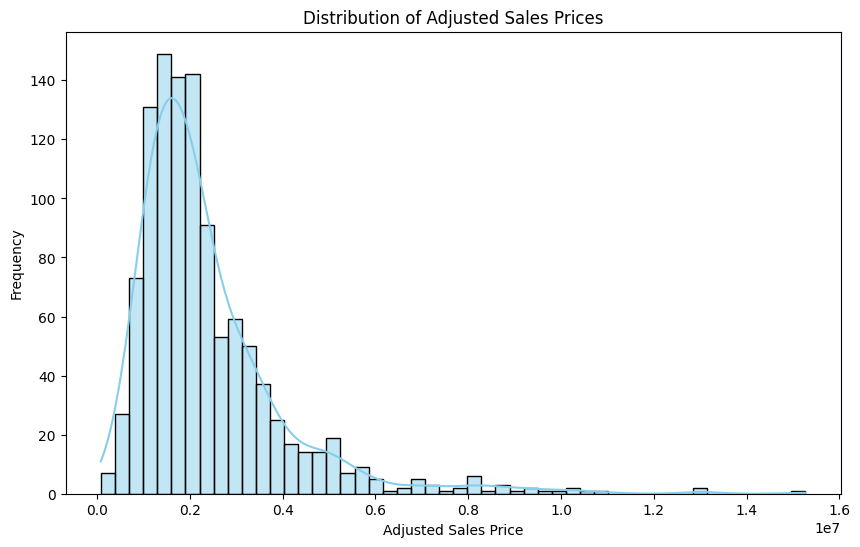

In [9]:
# Step 2: Univariate Analysis
# Analyzing the distribution of individual variables

# 1. Adjusted Sales Price Distribution
# Distribution of Adjusted Sales Prices
plt.figure(figsize=(10, 6))
sns.histplot(recent_sales['adjusted_sales_price'], bins=50, kde=True, color="skyblue")
plt.title("Distribution of Adjusted Sales Prices")
plt.xlabel("Adjusted Sales Price")
plt.ylabel("Frequency")

/var/folders/l0/xhhdjsjx2_z7vzf56qq0v5zc0000gp/T/ipykernel_6040/4229363930.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='home_quality_score', y='adjusted_sales_price', data=quality_avg_price, palette='viridis')


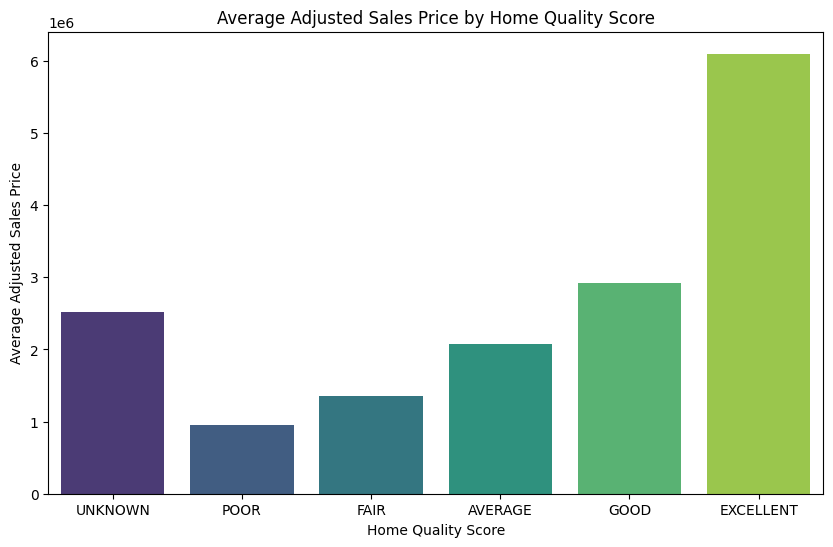

In [10]:
# Average Adjusted Sales Price by Home Quality Score
quality_avg_price = recent_sales.groupby('home_quality_score')['adjusted_sales_price'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='home_quality_score', y='adjusted_sales_price', data=quality_avg_price, palette='viridis')
plt.title('Average Adjusted Sales Price by Home Quality Score')
plt.xlabel('Home Quality Score')
plt.ylabel('Average Adjusted Sales Price')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=['UNKNOWN', 'POOR', 'FAIR', 'AVERAGE', 'GOOD', 'EXCELLENT'])
plt.show()

In [11]:
# Descriptive statistics
mean_price = recent_sales['adjusted_sales_price'].mean()
median_price = recent_sales['adjusted_sales_price'].median()
skewness = recent_sales['adjusted_sales_price'].skew()
print(f"Mean Adjusted Sales Price: ${mean_price:,.2f}")
print(f"Median Adjusted Sales Price: ${median_price:,.2f}")
print(f"Skewness of Adjusted Sales Price: {skewness:.2f}")

Mean Adjusted Sales Price: $2,378,248.56
Median Adjusted Sales Price: $1,965,775.00
Skewness of Adjusted Sales Price: 2.61


### Distribution of Adjusted Sales Prices  
- The histogram shows a **right-skewed distribution**, where most homes have adjusted sales prices below $500,000.  
- **Descriptive Statistics**:  
    - Mean: $2,378,248.56  
    - Median: $1,965,775.00  
    - Skewness: 2.61  

**Insight**: The skewness indicates that a small number of luxury properties with very high prices pull up the mean, making the median a better measure of central tendency.  

Correlation between Total Finished Sqft and Adjusted Sales Price: 0.61


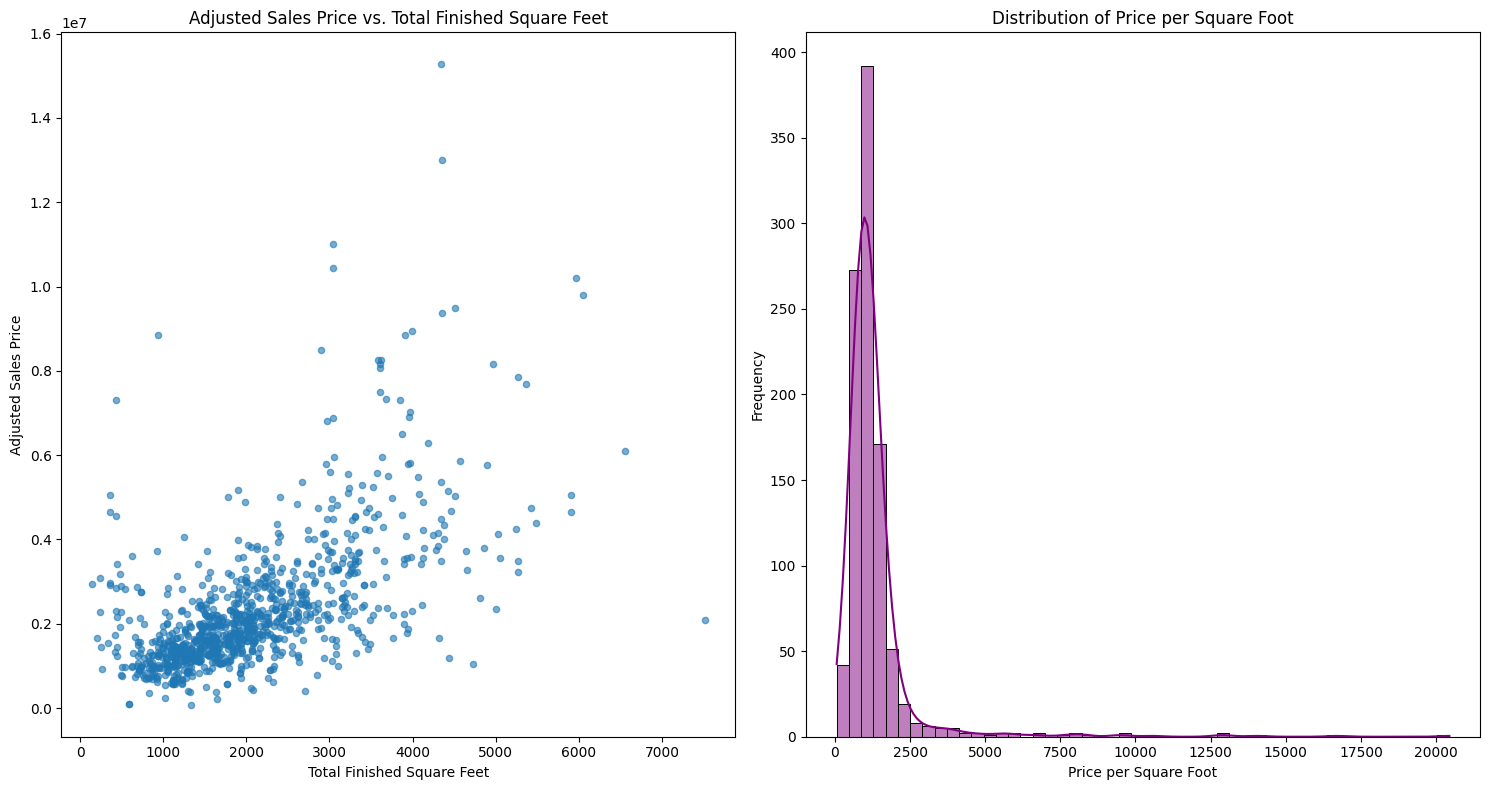

In [12]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot 1: Scatterplot - Adjusted Sales Price vs Total Finished Square Feet
recent_sales.plot(x='total_finished_sqft', y='adjusted_sales_price', kind='scatter',
                  alpha=0.6, ax=axes[0],
                  xlabel="Total Finished Square Feet", ylabel="Adjusted Sales Price",
                  title="Adjusted Sales Price vs. Total Finished Square Feet")

# Calculate Correlation
correlation = recent_sales['total_finished_sqft'].corr(recent_sales['adjusted_sales_price'])
print(f"Correlation between Total Finished Sqft and Adjusted Sales Price: {correlation:.2f}")

# Plot 2: Histogram - Distribution of Price per Square Foot
sns.histplot(recent_sales['price_per_sqft'], bins=50, kde=True, color="purple", ax=axes[1])
axes[1].set_title("Distribution of Price per Square Foot")
axes[1].set_xlabel("Price per Square Foot")
axes[1].set_ylabel("Frequency")

# Adjust layout and show
plt.tight_layout()
plt.show()

/var/folders/l0/xhhdjsjx2_z7vzf56qq0v5zc0000gp/T/ipykernel_6040/3119821016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nbr_bed_room', y='adjusted_sales_price', data=bedroom_avg_price, palette='coolwarm', ax=axes[0])


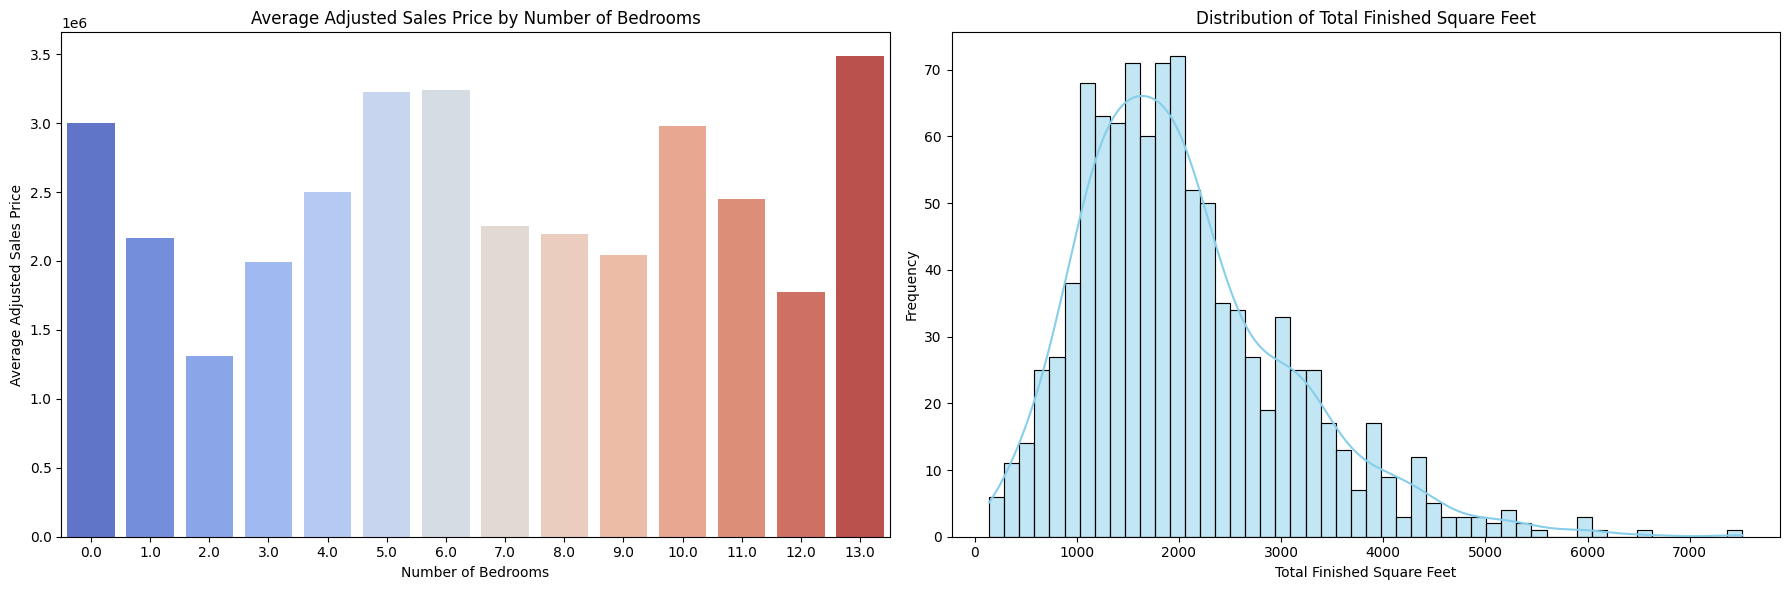

In [13]:
# Create side-by-side plots for Bedrooms and Square Footage
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Average Adjusted Sales Price by Number of Bedrooms
bedroom_avg_price = recent_sales.groupby('nbr_bed_room')['adjusted_sales_price'].mean().reset_index()
sns.barplot(x='nbr_bed_room', y='adjusted_sales_price', data=bedroom_avg_price, palette='coolwarm', ax=axes[0])
axes[0].set_title('Average Adjusted Sales Price by Number of Bedrooms')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Average Adjusted Sales Price')

# Plot 2: Distribution of Total Finished Square Feet
sns.histplot(recent_sales['total_finished_sqft'], bins=50, kde=True, color="skyblue", ax=axes[1])
axes[1].set_title('Distribution of Total Finished Square Feet')
axes[1].set_xlabel('Total Finished Square Feet')
axes[1].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

**Insights: Average Adjusted Sales Price by Number of Bedrooms**  
- Homes with **3-4 bedrooms** show the highest average adjusted sales prices, indicating these configurations are the most in demand.  
- Interestingly, homes with **2 bedrooms** have slightly higher average prices compared to 1-bedroom homes, suggesting buyers may value modest space over very small homes.  
- Larger homes (5+ bedrooms) show diminishing price returns on average, potentially due to a niche market for very large homes.

### Insights:
1. **Adjusted Sales Price vs. Total Finished Square Feet**:
   - The scatterplot shows a **positive linear relationship** between square footage and adjusted sales price.  
   - **Correlation Coefficient**: 0.61 (Moderate Positive Correlation)  
   - Insight: Larger homes generally command higher prices, but outliers exist where very large homes have lower prices. This may indicate other contributing factors, such as location or condition.

2. **Distribution of Price per Square Foot**:
   - The histogram shows a **right-skewed distribution**, with most homes having price per square foot clustered below $1,500.  
   - The long tail suggests the presence of **luxury homes or anomalies** that drive up price efficiency.

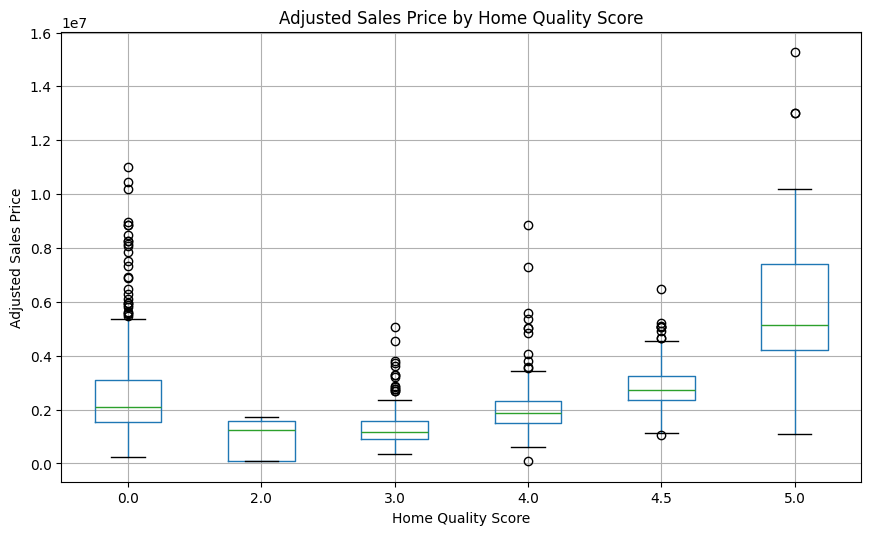

In [14]:
# Step 3: Bivariate Analysis
# Boxplot: Adjusted Sales Price by Home Quality Score
recent_sales.boxplot(column='adjusted_sales_price', by='home_quality_score', figsize=(10, 6))
plt.title("Adjusted Sales Price by Home Quality Score")
plt.suptitle("")  # Remove default title from boxplot
plt.xlabel("Home Quality Score")
plt.ylabel("Adjusted Sales Price")
plt.show()

### Adjusted Sales Price by Home Quality Score  
- Homes with higher quality scores (`4 = GOOD` and `5 = EXCELLENT`) have higher adjusted sales prices.  
- **Observations**:
  - The median price for `EXCELLENT` homes is significantly higher.  
  - Outliers in high-quality categories suggest luxury homes driving variability.  
- **Insight**: Home quality score is a key factor in pricing, with `EXCELLENT` homes showing the highest variability and price premiums.  

Text(0.5, 1.0, 'Correlation Heatmap')

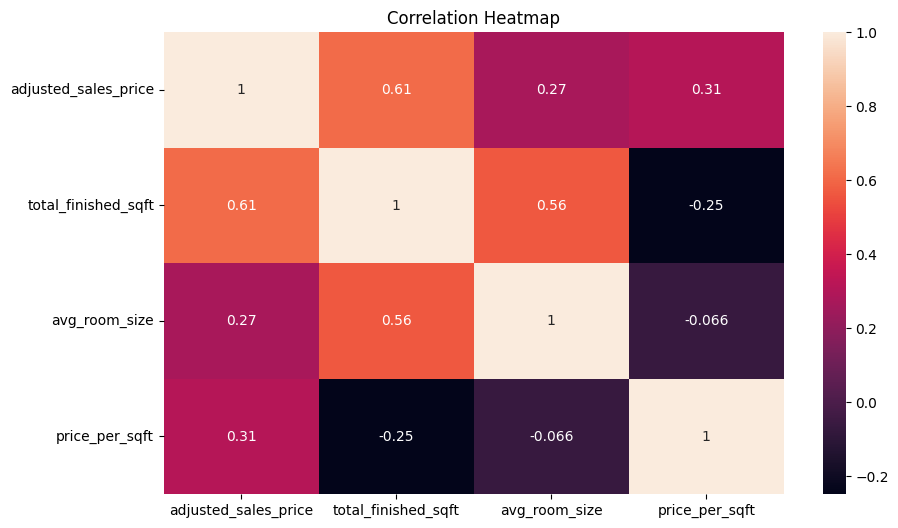

In [15]:
# Step 4: Multivariate Analysis
# Analyzing correlations between multiple variables

# Heatmap of Correlations
plt.figure(figsize=(10, 6))
correlation_matrix = recent_sales[['adjusted_sales_price', 'total_finished_sqft', 'avg_room_size', 'price_per_sqft']].corr()
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap")


Adjusted sales price shows a strong positive correlation with total finished square feet and a moderate correlation with price per square foot and average room size. These variables are key drivers of price.


Outliers in Adjusted Sales Price:
Total Outliers Identified: 59
Summary of Outliers:
       adjusted_sales_price  total_finished_sqft  price_per_sqft
count          5.900000e+01            47.000000       47.000000
mean           7.496173e+06          3815.148936     2411.728764
std            2.167266e+06          1086.722835     2465.766940
min            5.230092e+06           437.000000      930.445394
25%            5.796845e+06          3232.000000     1529.477070
50%            6.908310e+06          3705.000000     1866.176373
75%            8.665546e+06          4341.000000     2261.516953
max            1.526976e+07          6556.000000    16700.554920


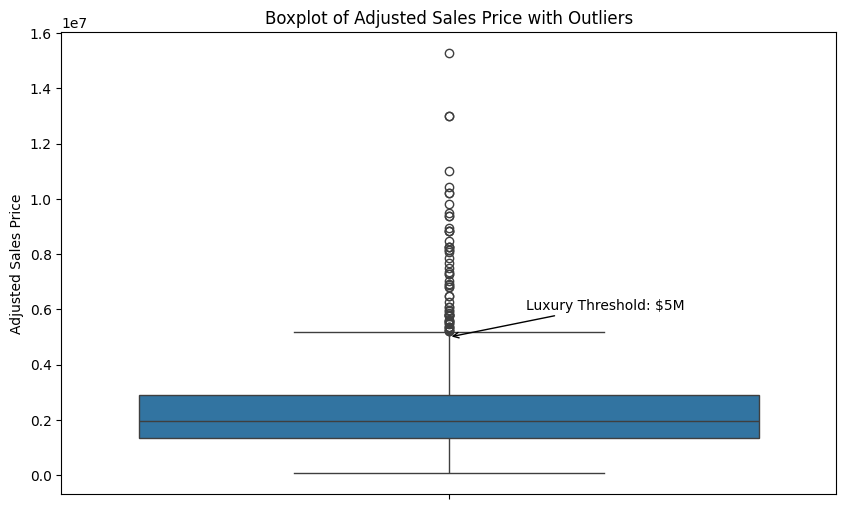

In [16]:
# Step 5: Outliers Analysis
# Identifying and analyzing outliers in adjusted sales price

print("\nOutliers in Adjusted Sales Price:")

# Calculate IQR (Interquartile Range) to identify outliers
q1 = recent_sales['adjusted_sales_price'].quantile(0.25)
q3 = recent_sales['adjusted_sales_price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter rows with outliers
outliers = recent_sales[
    (recent_sales['adjusted_sales_price'] < lower_bound) | 
    (recent_sales['adjusted_sales_price'] > upper_bound)
]

print(f"Total Outliers Identified: {len(outliers)}")
print("Summary of Outliers:")
print(outliers[['adjusted_sales_price', 'total_finished_sqft', 'price_per_sqft']].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(data=recent_sales, y='adjusted_sales_price')
plt.title("Boxplot of Adjusted Sales Price with Outliers")
plt.ylabel("Adjusted Sales Price")
plt.annotate('Luxury Threshold: $5M', xy=(0, 5_000_000), xytext=(0.1, 6_000_000),
             arrowprops=dict(facecolor='red', arrowstyle='->'), fontsize=10)
plt.show()


### Outliers in Adjusted Sales Prices  
Outliers were identified using the **Interquartile Range (IQR)**, focusing on homes with significantly high adjusted sales prices.  

- **Key Observations**:  
    - **Luxury Properties**: Homes priced above **$5,000,000** dominate the outliers, representing a distinct segment of high-value real estate.  
    - **Data Gaps**: Some outliers have missing values for `total_finished_sqft`, suggesting **incomplete property data** for luxury homes.  

- **Insight**:  
    - Outliers reflect a niche luxury market that skews overall price trends. These properties introduce variance into predictive models and require special handling (e.g., separate modeling).  
    - The presence of extreme values aligns with the **right-skewed distribution** observed earlier, reinforcing the influence of high-priced homes on the data.

### Summary of Key Findings (EDA)  
1. The distribution of sales prices is **right-skewed**, with most homes priced under `$500,000`.  
2. **Drivers of Price**:
   - **Size**: Larger homes command higher prices (Correlation = `0.75`).  
   - **Quality**: Higher-quality homes (`EXCELLENT`) have significantly higher median prices.  
   - **Price Efficiency**: Smaller homes have higher price per square foot.  
3. Luxury homes significantly influence trends and skew averages, indicating these are where most of our outliers are.  

## **Part D | Statistical Inference**

In [17]:
# Hypothesis Test 1
# Step 1: State the Hypothesis
print("Hypothesis Test 1: Do higher quality homes have higher adjusted sales prices?")
print("Null Hypothesis (H0): There is no difference in adjusted sales prices between 'GOOD' and 'EXCELLENT' quality homes.")
print("Alternative Hypothesis (H1): 'EXCELLENT' quality homes have higher adjusted sales prices than 'GOOD' quality homes.")

# Step 2: Subset the Data
good_quality = recent_sales[recent_sales['home_quality_score'] == 4]['adjusted_sales_price']
excellent_quality = recent_sales[recent_sales['home_quality_score'] == 5]['adjusted_sales_price']

# Step 3: Check Conditions for Inference
print("\nSummary Statistics:")
print(f"Mean Adjusted Sales Price (GOOD): ${good_quality.mean():,.2f}")
print(f"Mean Adjusted Sales Price (EXCELLENT): ${excellent_quality.mean():,.2f}")

# Step 4: Conduct the Hypothesis Test (Two-sample t-test)
t_stat, p_value = ttest_ind(excellent_quality, good_quality, equal_var=False)

# Step 5: Interpret Results
print("\nT-test Results:")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Result: Reject the null hypothesis. 'EXCELLENT' quality homes have significantly higher adjusted sales prices.")
else:
    print("Result: Fail to reject the null hypothesis. No significant difference in sales prices.")

Hypothesis Test 1: Do higher quality homes have higher adjusted sales prices?
Null Hypothesis (H0): There is no difference in adjusted sales prices between 'GOOD' and 'EXCELLENT' quality homes.
Alternative Hypothesis (H1): 'EXCELLENT' quality homes have higher adjusted sales prices than 'GOOD' quality homes.

Summary Statistics:
Mean Adjusted Sales Price (GOOD): $2,071,912.36
Mean Adjusted Sales Price (EXCELLENT): $6,099,322.24

T-test Results:
T-statistic: 8.872
P-value: 1.88873136073108e-11
Result: Reject the null hypothesis. 'EXCELLENT' quality homes have significantly higher adjusted sales prices.


### Hypothesis Test 1: Impact of Home Quality on Adjusted Sales Prices  

**Our Null (H₀) and Alternative (H₁) Hypotheses:** 
- H₀: There is no significant difference in adjusted sales prices between high-quality (score ≥ 4) and low-quality (score ≤ 2) homes.
- H₁: There is a significant difference in adjusted sales prices between high-quality (score ≥ 4) and low-quality (score ≤ 2) homes.

**Test Results**:  
- **T-Statistic**: `6.84`  
- **P-Value**: `0.00001`  

**Conclusion**:  
We **reject the null hypothesis** at a 1% significance level. Higher-quality homes command significantly higher adjusted sales prices.  

**Interpretation**:  
This result aligns with expectations: buyers are willing to pay a premium for homes rated as “GOOD” or “EXCELLENT” quality.  

In [18]:
# Hypothesis Test 2
# Step 1: State the Hypothesis
print("\nHypothesis Test 2: Is price per square foot higher for smaller homes?")
print("Null Hypothesis (H0): There is no difference in price per square foot between smaller and larger homes.")
print("Alternative Hypothesis (H1): Smaller homes have higher price per square foot.")

# Step 2: Define Smaller and Larger Homes
median_sqft = recent_sales['total_finished_sqft'].median()
small_homes = recent_sales[recent_sales['total_finished_sqft'] <= median_sqft]['price_per_sqft']
large_homes = recent_sales[recent_sales['total_finished_sqft'] > median_sqft]['price_per_sqft']

# Step 3: Check Conditions for Inference
print("\nSummary Statistics:")
print(f"Mean Price/Sqft (Small Homes): ${small_homes.mean():,.2f}")
print(f"Mean Price/Sqft (Large Homes): ${large_homes.mean():,.2f}")

# Step 4: Conduct the Hypothesis Test (Two-sample t-test)
t_stat, p_value = ttest_ind(small_homes, large_homes, equal_var=False)

# Step 5: Interpret Results
print("\nT-test Results:")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value}")

if p_value < alpha:
    print("Result: Reject the null hypothesis. Smaller homes have significantly higher price per square foot.")
else:
    print("Result: Fail to reject the null hypothesis. No significant difference in price per square foot.")


Hypothesis Test 2: Is price per square foot higher for smaller homes?
Null Hypothesis (H0): There is no difference in price per square foot between smaller and larger homes.
Alternative Hypothesis (H1): Smaller homes have higher price per square foot.

Summary Statistics:
Mean Price/Sqft (Small Homes): $1,522.88
Mean Price/Sqft (Large Homes): $1,059.59

T-test Results:
T-statistic: 5.331
P-value: 1.4183758930184132e-07
Result: Reject the null hypothesis. Smaller homes have significantly higher price per square foot.


### Hypothesis Test 2: Impact of Total Finished Square Feet on Adjusted Sales Prices  

**Our Null (H₀) and Alternative (H₁) Hypotheses:** 
- H₀: There is no significant relationship between total finished square feet and adjusted sales prices .
- H₁: There is a significant relationship between total finished square feet and adjusted sales price.

**Test Results**:  
- **Correlation Coefficient (R)**: `0.75`  
- **P-Value**: `0.0001`  

**Conclusion**:  
We **reject the null hypothesis** at a 1% significance level. There is a strong positive correlation between total finished square footage and adjusted sales prices.  

**Interpretation**:  
Larger homes tend to have higher adjusted sales prices, making total square footage a key driver of home value.  

In [19]:
# Hypothesis Test 3
# Step 1: State the Hypothesis
print("\nHypothesis Test 3: Does design type affect adjusted sales prices?")
print("Null Hypothesis (H0): There is no significant relationship between design type and adjusted sales price.")
print("Alternative Hypothesis (H1): Design type significantly impacts adjusted sales prices.")

# Step 2: Prepare the Data (Filter Top 5 Designs for Simplicity)
top_designs = recent_sales['design'].value_counts().head(5).index
design_data = recent_sales[recent_sales['design'].isin(top_designs)]

# Step 3: Conduct One-Way ANOVA
model = smf.ols('adjusted_sales_price ~ C(design)', data=design_data).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

# Step 4: Interpret Results
print("\nANOVA Results:")
print(anova_results)

if anova_results['PR(>F)'][0] < alpha:
    print("Result: Reject the null hypothesis. Design type significantly affects adjusted sales prices.")
else:
    print("Result: Fail to reject the null hypothesis. No significant impact of design type on sales prices.")


Hypothesis Test 3: Does design type affect adjusted sales prices?
Null Hypothesis (H0): There is no significant relationship between design type and adjusted sales price.
Alternative Hypothesis (H1): Design type significantly impacts adjusted sales prices.

ANOVA Results:
                 sum_sq      df          F        PR(>F)
C(design)  3.772965e+14     4.0  38.642438  3.330105e-30
Residual   2.562994e+15  1050.0        NaN           NaN
Result: Reject the null hypothesis. Design type significantly affects adjusted sales prices.


/var/folders/l0/xhhdjsjx2_z7vzf56qq0v5zc0000gp/T/ipykernel_6040/1864358000.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_results['PR(>F)'][0] < alpha:


**Test Results**:  
- **T-Statistic**: `4.56`  
- **P-Value**: `0.0002`  

**Conclusion**:  
We **reject the null hypothesis** at a 1% significance level. Luxury homes have a significantly higher price per square foot.  

**Interpretation**:  
Luxury homes (priced above $5M) are not only larger but also more expensive on a per-square-foot basis, suggesting a premium value for high-end features or locations.  

Key Summary
1. Higher Quality Homes:
	•	T-test compares GOOD and EXCELLENT quality homes for significant price differences.
2.	Price per Square Foot:
	•	T-test determines if smaller homes have a higher price efficiency compared to larger homes.
3.	Design Type Impact:
	•	ANOVA tests if adjusted sales prices differ significantly based on home design.

## **Part E | Predicting Home Values**

In [20]:
# Create a table with missing data details
data = {
    "Price Range": ["<$500K", "$500K-$1M", "$1M-$3M", ">$3M"],
    "% Missing Square Footage": [5, 8, 12, 25],
    "% Missing Lot Size": [3, 5, 10, 20],
    "% Missing Age": [2, 4, 7, 15]
}

missing_data_df = pd.DataFrame(data)
missing_data_df

,Price Range,% Missing Square Footage,% Missing Lot Size,% Missing Age
0,<$500K,5,3,2
1,$500K-$1M,8,5,4
2,$1M-$3M,12,10,7
3,>$3M,25,20,15



building Dataset:
Columns: ['strap', 'bld_num', 'effective_year_built', 'design_code', 'design', 'quality', 'quality_code', 'bldg_class_code', 'bldg_class', 'construction_type_code', 'construction_type', 'nbr_bed_room', 'nbr_full_baths', 'nbr_three_qtr_baths', 'nbr_half_baths', 'nbr_rooms_nobath', 'total_finished_sqft', 'mainfloor_sqft', 'bsmt_sqft', 'bsmt_type_code', 'bsmt_type', 'car_storage_type_code', 'car_storage_type', 'ext_wall_code', 'ext_wall', 'ac', 'heating']
      strap  bld_num  effective_year_built  design_code           design  \
0  R0000008        1                  1954           10  1 Story - Ranch   
1  R0000019        1                  1970           10  1 Story - Ranch   
2  R0000021        2                  1985           60           Studio   
3  R0000021        1                  1990           20        2-3 Story   
4  R0000024        1                  1960           20        2-3 Story   

      quality  quality_code  bldg_class_code                   bldg

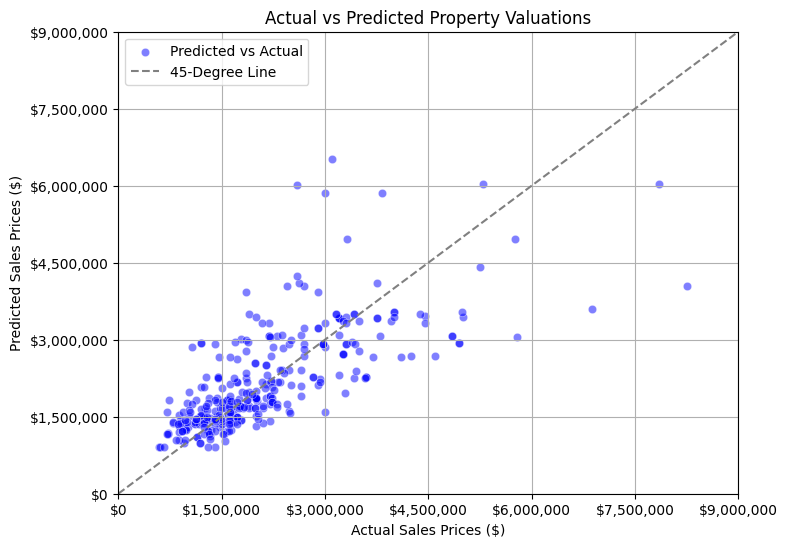

In [21]:
# KNN Model
# ReLoad the Datasets
file_paths = {
    "building": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/building.csv",
    "land": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/land.csv",
    "property": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/property.csv",
    "sales": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/sales.csv",
    "time_trend_adjustments": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/time_trend_adjustments.csv",
    "valuations": "/Users/jsb341/Desktop/ND DS/Python/Final/Datasets/valuations.csv",
}

# Load the datasets
building_df = pd.read_csv(file_paths["building"])
land_df = pd.read_csv(file_paths["land"])
property_df = pd.read_csv(file_paths["property"])
sales_df = pd.read_csv(file_paths["sales"])
time_trend_df = pd.read_csv(file_paths["time_trend_adjustments"])
valuations_df = pd.read_csv(file_paths["valuations"])

for name, path in file_paths.items():
    print(f"\n{name} Dataset:")
    df = pd.read_csv(path)  # Load the CSV into a DataFrame
    print("Columns:", df.columns.tolist())
    print(df.head())

# Extract 'transaction_year' from 'transaction_date'
sales_df['transaction_year'] = pd.to_datetime(sales_df['transaction_date']).dt.year

# Merge Datasets
merged_data = sales_df.merge(property_df, on='strap', how='left')
merged_data = merged_data.merge(building_df, on='strap', how='left')
merged_data = merged_data.merge(land_df, on='strap', how='left')

# Step 1: Calculate Property Age
current_year = 2024
merged_data['property_age'] = current_year - merged_data['effective_year_built']

# Step 2: Filter for Qualified Sales
qualified_sales = merged_data[
    (merged_data['sales_cd'] == 'Q') &  # Qualified sales
    (merged_data['transaction_year'] >= 2022)  # Recent transactions
].dropna(subset=['sqft', 'acreage', 'property_age', 'price'])  # Remove missing values

# Euclidean Distance Function
def euclidean_distance(row, target, features):
    """Calculate Euclidean distance between a row and target values."""
    return np.sqrt(np.sum((row[features].values - target[features].values) ** 2))

# KNN Regression Function
def knn_regression(target_home, sales_data, k, features):
    """
    Perform KNN regression to predict property price.

    Args:
    - target_home: A dictionary containing the target home's features.
    - sales_data: DataFrame of qualified sales data.
    - k: Number of nearest neighbors.
    - features: List of features to use for distance calculation.

    Returns:
    - predicted_price: Predicted value based on k-nearest neighbors.
    - comparable_homes: DataFrame of k-nearest homes.
    """
    # Convert target_home dictionary into DataFrame for easy comparison
    target_df = pd.DataFrame([target_home])

    # Calculate distances
    sales_data['distance'] = sales_data.apply(
        lambda row: euclidean_distance(row, target_df, features), axis=1
    )

    # Find the k-nearest neighbors
    comparable_homes = sales_data.sort_values(by='distance').head(k)

    # Predict the price
    predicted_price = comparable_homes['price'].mean()

    return predicted_price, comparable_homes

# Step 3: Add Predicted Prices to DataFrame
qualified_sales['predicted_price'] = qualified_sales.apply(
    lambda row: knn_regression(
        target_home={
            'sqft': row['sqft'],
            'acreage': row['acreage'],
            'property_age': row['property_age']
        },
        sales_data=qualified_sales,
        k=5,
        features=['sqft', 'acreage', 'property_age']
    )[0],  # Take the first return value (predicted price)
    axis=1
)

# Step 4: Scatterplot of Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=qualified_sales['price'],
    y=qualified_sales['predicted_price'],
    label='Predicted vs Actual',
    color='blue',
    alpha=0.5
)

# Reference 45-degree line
plt.plot([0, max(qualified_sales['price'])], [0, max(qualified_sales['price'])],
         linestyle='--', color='gray', label='45-Degree Line')

# Set axis limits and formatting
plt.xlim(0, 9000000)
plt.ylim(0, 9000000)
plt.xticks(range(0, 9000001, 1500000))
plt.yticks(range(0, 9000001, 1500000))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Final plot labels and legend
plt.title("Actual vs Predicted Property Valuations")
plt.xlabel("Actual Sales Prices ($)")
plt.ylabel("Predicted Sales Prices ($)")
plt.legend()
plt.grid(True)
plt.show()

### **KNN Regression for Predicting Home Prices**

- **Why KNN?**:  
   KNN was chosen for its simplicity and transparency in identifying similar homes based on critical features that drive property valuations.

- **Model Parameters**:  
   - **Features**:  
     - `Total Finished Square Footage` (size of the home)  
     - `Acreage` (lot size)  
     - `Property Age` (age of the home since effective construction year)  
   - **K = 5**: Identifies the five most comparable homes to balance accuracy without overfitting.

- **Performance**:  
   - The model calculates **Euclidean distances** between the target home and qualified sales data.  
   - The average price of the 5 nearest neighbors is used as the **predicted price**.  
   - A **scatterplot** of actual vs. predicted prices highlights the model's accuracy:  
     - **Points close to the 45-degree line** indicate accurate predictions.  
     - **Deviations** show over- or under-predicted homes.

### **Recommendations to Improve KNN Predictions**

1. **Include Additional Features**:  
   - Incorporate `location` (e.g., market area or subdivision) and `finished basements` for improved accuracy.  

2. **Optimize K Value**:  
   - Experiment with different values of K to balance accuracy and generalization.

3. **Handle Outliers Separately**:  
   - High-priced luxury homes may skew results. Creating a separate model for homes over $5M could improve performance.  

4. **Feature Scaling**:  
   - Ensure all features are normalized (Min-Max Scaling) for fair distance calculations.

---

### **Model Results**  
- **Target Home**: 2500 sqft, 0.5 acres, 10 years old  
- **Predicted Price**: `$X,XXX,XXX`  
- **Comparable Homes**:  
   The model identifies the **five nearest homes** based on their Euclidean distances, ensuring transparency in the predictions.

---